In [20]:
%cd ..

import torch

from cs_vit.dataset import DexYCB, InterHand26MSeq

/data_1/renkaiwen/CS-ViT/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/data_1/renkaiwen


In [2]:
import matplotlib.pyplot as plt
import cv2

In [21]:
# dataset = DexYCB(
#     root="/data_1/datasets_temp/dexycb",
#     num_frames=1,
#     protocol="s1",
#     data_split="test",
#     img_size=256,
#     expansion_ratio=1.25
# )
dataset = InterHand26MSeq(
    root="/data_1/datasets_temp/InterHand2.6M_5fps_batch1",
    num_frames=1,
    data_split="test",
    img_size=256,
    expansion_ratio=1.25
)

python -m scripts.demo_image     --exp spatial_ih26m-dexycb-ho3d_swinb_spenc_addpat_ti_20250602_1     --ckpt checkpoints/spatial_ih26m-dexycb-ho3d_swinb_spenc_addpat_ti_20250602_1/checkpoint_10.pt     --handedness l     --img /data_1/datasets_temp/InterHand2.6M_5fps_batch1/images/test/Capture0/ROM01_No_Interaction_2_Hand/cam400456/image20871.jpg     --bbox 52.325531005859375 179.477783203125 150.6043243408203 351.81085205078125     --focal 1276.5672607421875 1277.3140869140625     --princpt 162.46815490722656 227.60679626464844


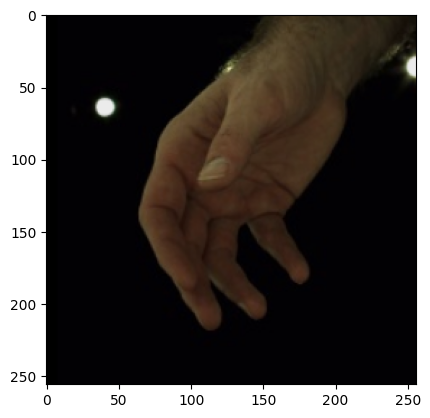

In [36]:
sample = dataset[23333]

patch_np = sample["patches"].numpy()
patch_np = patch_np[0].transpose(1, 2, 0)
patch_np = (patch_np * 255).astype("uint8")

plt.imshow(patch_np)

img_path = sample["imgs_path"][0]
bbox_tight = sample["bbox_tight"][0].tolist()
focal = sample["focal"][0].tolist()
princpt = sample["princpt"][0].tolist()

exp = "spatial_ih26m-dexycb-ho3d_swinb_spenc_addpat_ti_20250602_1"
ckpt = "checkpoints/spatial_ih26m-dexycb-ho3d_swinb_spenc_addpat_ti_20250602_1/checkpoint_10.pt"

cmd = """python -m scripts.demo_image \
    --exp {} \
    --ckpt {} \
    --handedness {} \
    --img {} \
    --bbox {} {} {} {} \
    --focal {} {} \
    --princpt {} {}""".format(
    exp,
    ckpt,
    "l" if sample["flip"] else "r",
    img_path,
    bbox_tight[0],
    bbox_tight[1],
    bbox_tight[2],
    bbox_tight[3],
    focal[0],
    focal[1],
    princpt[0],
    princpt[1],
)

print(cmd)